In [ ]:
import pandas as pd
import numpy as np
import joblib
import shap

In [4]:
df = pd.read_csv(
    "../data/processed/featured_uhi_v2.csv"
)

df.head()

,Elevation,LST,Latitude,Longitude,NDBI,NDVI,Population,Green_Built_Ratio,Population_Heat_Index,Elevation_Cooling_Index
0,919,43.919170,19.970832,75.438700,0.127207,0.162286,1.562392,1.182783,0.198747,149.140825
1,488,39.060455,19.729093,75.209548,-0.272423,0.570751,1.361367,2.020910,-0.370867,278.526341
2,505,40.231127,19.788775,75.225639,0.055877,0.099371,15.386780,1.508423,0.859774,50.182390
3,757,44.884761,19.960297,75.544582,0.121404,0.196037,2.643492,1.491866,0.320931,148.400233
4,586,48.502735,19.867709,75.486062,0.133151,0.165262,31.397209,1.154459,4.180581,96.843708


In [ ]:
FEATURES = ["NDVI", "NDBI", "Elevation", "Population"]
X = df[FEATURES]
y = df["LST"]

model = joblib.load("../outputs/lst_model_xgb_v3.pkl")
print("Loaded XGBoost V3 model")

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Model Trained")

Model Trained


In [13]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,NDBI,0.427235
5,Longitude,0.108310
6,Green_Built_Ratio,0.102589
4,Latitude,0.080634
2,Elevation,0.072561
3,Population,0.065674
8,Elevation_Cooling_Index,0.049683
0,NDVI,0.046984
7,Population_Heat_Index,0.046332


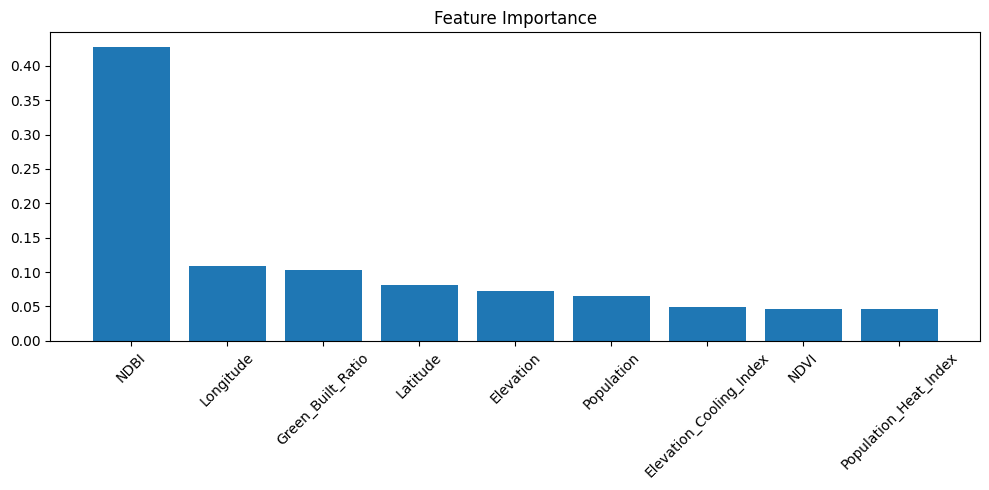

In [14]:
plt.figure(figsize=(10,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

In [18]:
feature_importance.to_csv(
    "../outputs/feature_importance_v2.csv",
    index=False
)

print("Feature Importance Saved")

Feature Importance Saved
